In [8]:
import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from keras import layers
import os

In [9]:
os.chdir(r'C:\Users\PC\Documents\Proj_MPA\Recontrucao\Sergipe\1-Crustaceos')

Epoch 1/100


c:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.0189
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0045
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9486
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9666
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9727
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8506
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8739
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8238
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8918
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8477
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8935
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8743
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8304
Epoch 14/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8114
Epoch 15/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7898
Epoch 16/100
2/2 ━━━━━━━━━━━━━━

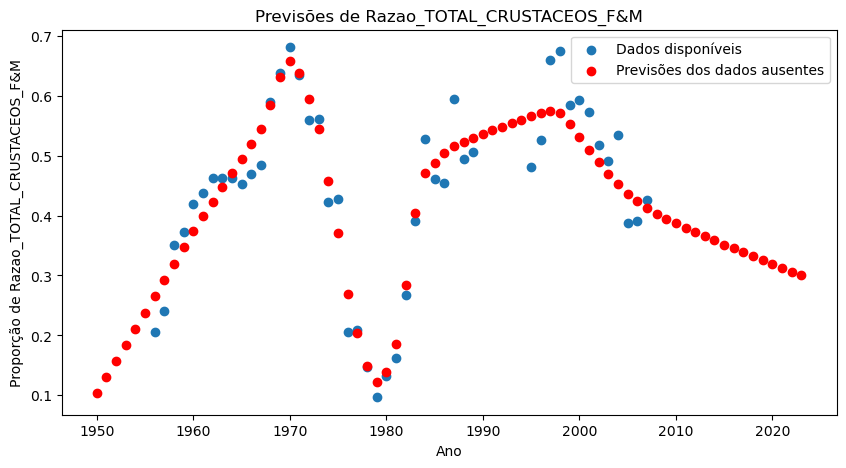

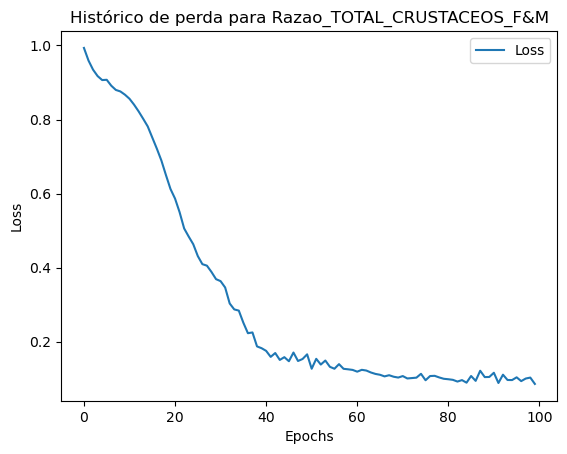

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Previsões para Razao_TOTAL_CRUSTACEOS_F&M: [[0.10439456]
 [0.1305227 ]
 [0.15674865]
 [0.18355933]
 [0.21087533]
 [0.23811936]
 [0.26536328]
 [0.29261   ]
 [0.31985942]
 [0.3471089 ]
 [0.37427294]
 [0.39920545]
 [0.42309636]
 [0.44697765]
 [0.47085905]
 [0.49474025]
 [0.51862156]
 [0.5438376 ]
 [0.58525634]
 [0.6312518 ]
 [0.65857565]
 [0.63826215]
 [0.5941411 ]
 [0.5436114 ]
 [0.4581628 ]
 [0.37074953]
 [0.26939037]
 [0.2044091 ]
 [0.14890775]
 [0.12256783]
 [0.13908312]
 [0.18530932]
 [0.2837842 ]
 [0.40489766]
 [0.47175992]
 [0.488422  ]
 [0.5037794 ]
 [0.515975  ]
 [0.5229783 ]
 [0.52947354]
 [0.5358902 ]
 [0.542205  ]
 [0.54832083]
 [0.5540887 ]
 [0.5599113 ]
 [0.5656438 ]
 [0.5707606 ]
 [0.57499653]
 [0.57116747]
 [0.55289197]
 [0.531351  ]
 [0.5098101 ]
 [0.4890298 ]
 [0.46985152]
 [0.45214537]
 [0.4364866 ]
 [0.42357808]
 [0.41300237]
 [0.40319145]
 [0.39474294]
 [0.3871375 ]
 [0.3796749 ]
 [0.37264678]
 [0.36567128]
 [0.3586722 ]
 [0.35169

In [10]:
# Carregar o arquivo Excel
df = pd.read_excel('Extrapolacao_TOTAL_CRUSTACEOS_F&M.xlsx')

# Listar as espécies de interesse
tipos_especies = [
   'Razao_TOTAL_CRUSTACEOS_F&M'

]  # Adicione as espécies que você deseja

# Anos para prever
anos_para_prever = np.arange(1950, 2024)

# Iterar sobre cada espécie
for tipo in tipos_especies:
    # Selecionar as colunas necessárias e remover valores nulos
    dados = df[['Ano', tipo]].dropna()
    anos_com_dados = dados['Ano'].values
    especie_dados = dados[tipo].values

    # Normalizar os anos e os valores da espécie
    ano_mean = np.mean(anos_com_dados)
    ano_std = np.std(anos_com_dados)
    anos_com_dados_norm = (anos_com_dados - ano_mean) / ano_std
    anos_para_prever_norm = (anos_para_prever - ano_mean) / ano_std

    especie_mean = np.mean(especie_dados)
    especie_std = np.std(especie_dados)
    especie_norm = (especie_dados - especie_mean) / especie_std

    # Criar e compilar o modelo
    model = keras.Sequential([
        layers.Dense(96, activation='leaky_relu', input_shape=(1,)),
        layers.Dense(32, activation='leaky_relu'),
        layers.Dense(80, activation='leaky_relu'),
        layers.Dense(80, activation='leaky_relu'),
        layers.Dense(96, activation='leaky_relu'),
        layers.Dense(112, activation='leaky_relu'),
        layers.Dense(1, activation='linear')
    ])
    opt = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='mse')

    # Treinar o modelo
    history = model.fit(anos_com_dados_norm, especie_norm, epochs=100, verbose=1)
    model.save_weights(f'W_I_{tipo}.weights.h5', overwrite=True)

    # Carregar os pesos do modelo para previsões
    model.load_weights(f'W_I_{tipo}.weights.h5')

    # Previsões para os anos ausentes
    prev_ausentes = model.predict(anos_para_prever_norm) * especie_std + especie_mean

    # Corrigir valores negativos
    prev_ausentes = np.where(prev_ausentes < 0, 0, prev_ausentes)

    # Plotar os dados e as previsões
    plt.figure(figsize=(10, 5))
    plt.scatter(anos_com_dados, especie_dados, label='Dados disponíveis')
    plt.scatter(anos_para_prever, prev_ausentes, color='red', label='Previsões dos dados ausentes')
    plt.title(f'Previsões de {tipo}')
    plt.xlabel('Ano')
    plt.ylabel(f'Proporção de {tipo}')
    plt.legend()
    plt.show()

    # Plotar o histórico de perda
    plt.figure()
    plt.plot(history.history['loss'], label='Loss')
    plt.title(f'Histórico de perda para {tipo}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Salvar previsões contínuas para todos os anos
    anos = np.arange(1950, 2024)
    anos_norm = (anos - ano_mean) / ano_std
    prev_continua = model.predict(anos_norm) * especie_std + especie_mean
    prev_continua = np.where(prev_continua < 0, 0, prev_continua)
    np.save(f'prev_{tipo}', prev_continua)

    # Criar DataFrame de previsões
    df_previsoes = pd.DataFrame({'Ano': anos_para_prever, tipo: prev_ausentes.flatten()})
    
  
    # Concatenar com os dados originais e remover duplicatas, priorizando os dados originais
    df_preenchido = pd.concat((dados, df_previsoes)).sort_values('Ano').drop_duplicates(subset='Ano', keep='first')


    # Salvar o DataFrame preenchido em um arquivo Excel
    df_preenchido.to_excel(f'Interpolações_{tipo}.xlsx')

    print(f'Previsões para {tipo}:', prev_ausentes)